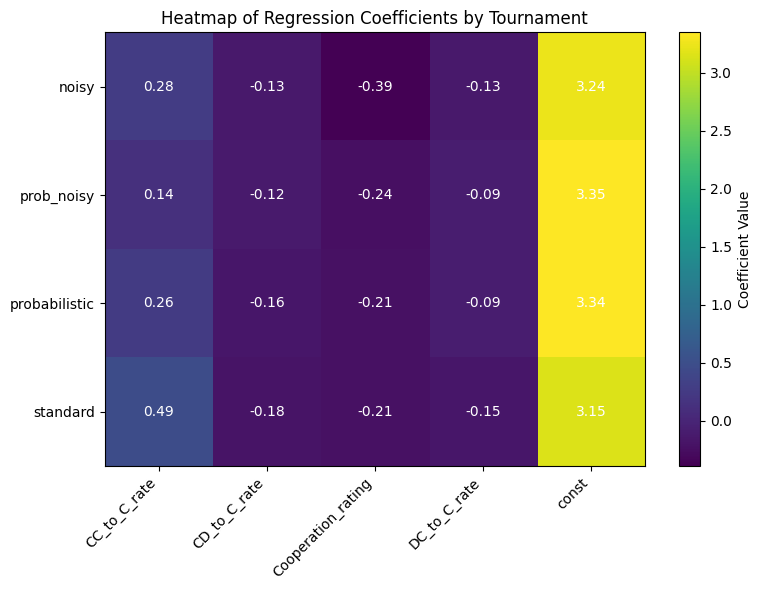

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

summary_csv = "regression_summary.csv"
if os.path.exists(summary_csv):
    df_combined = pd.read_csv(summary_csv, index_col=[0, 1])
else:
    raise FileNotFoundError(f"Could not find {summary_csv}. Run regression code first.")

coef_df = df_combined['coef'].unstack(level='feature')

# Plot 1: Heatmap of coefficients
plt.figure(figsize=(8, 6))
plt.imshow(coef_df, aspect='auto')
plt.colorbar(label='Coefficient Value')
plt.xticks(ticks=range(len(coef_df.columns)), labels=coef_df.columns, rotation=45, ha='right')
plt.yticks(ticks=range(len(coef_df.index)), labels=coef_df.index)
plt.title('Heatmap of Regression Coefficients by Tournament')

# Annotate each cell with its value
for i in range(len(coef_df.index)):
    for j in range(len(coef_df.columns)):
        value = coef_df.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha='center', va='center', color='white', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import dask.dataframe as dd

import imp

features = [
    "CC_to_C_rate",
    "CD_to_C_rate",
    "DC_to_C_rate",
    "DD_to_C_rate",
    "SSE",
    "Cooperation_rating",
    "Cooperation_rating_max",
    "Cooperation_rating_min",
    "Cooperation_rating_median",
    "Cooperation_rating_mean",
    "Cooperation_rating_comp_to_max",
    "Cooperation_rating_comp_to_min",
    "Cooperation_rating_comp_to_median",
    "Cooperation_rating_comp_to_mean",
    "repetitions",
]
dfs = []
for name in ['standard', 'noisy', 'probabilistic', 'prob_noisy']:
    df = pd.read_csv('../csv/%s_aggregated.csv' % name, index_col=0)
            
    df['type'] = name
    dfs.append(df)
types = ['standard', 'noisy', 'probabilistic', 'prob_noisy']
dfs[0].head()


/tmp/ipykernel_116774/3115960931.py:4: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp


,Name,Median_score,Cooperation_rating,Wins,Initial_C_rate,CC_rate,CD_rate,DC_rate,DD_rate,CC_to_C_rate,...,T,P,noise,prob_end,repetitions,turns,tournament,n_strategies,run,type
Rank,,,,,,,,,,,,,,,,,,,,,
0,Grudger,3.512917,0.671296,1.0,1.0,0.666667,0.004630,0.164352,0.164352,1.0,...,4.44,2.98,0.08,0.07,53,72,standard,7,1,standard
1,Evolved FSM 16,3.450694,0.780093,1.0,1.0,0.719907,0.060185,0.217593,0.002315,1.0,...,4.44,2.98,0.08,0.07,53,72,standard,7,1,standard
2,GTFT: 0.33,3.216713,0.929158,0.0,1.0,0.860194,0.068964,0.030922,0.039920,1.0,...,4.44,2.98,0.08,0.07,53,72,standard,7,1,standard
3,Tit For 2 Tats,3.212083,0.935185,0.0,1.0,0.863426,0.071759,0.032407,0.032407,1.0,...,4.44,2.98,0.08,0.07,53,72,standard,7,1,standard
4,Suspicious Tit For Tat,3.109074,0.682477,4.0,0.0,0.577918,0.104560,0.113819,0.203704,1.0,...,4.44,2.98,0.08,0.07,53,72,standard,7,1,standard


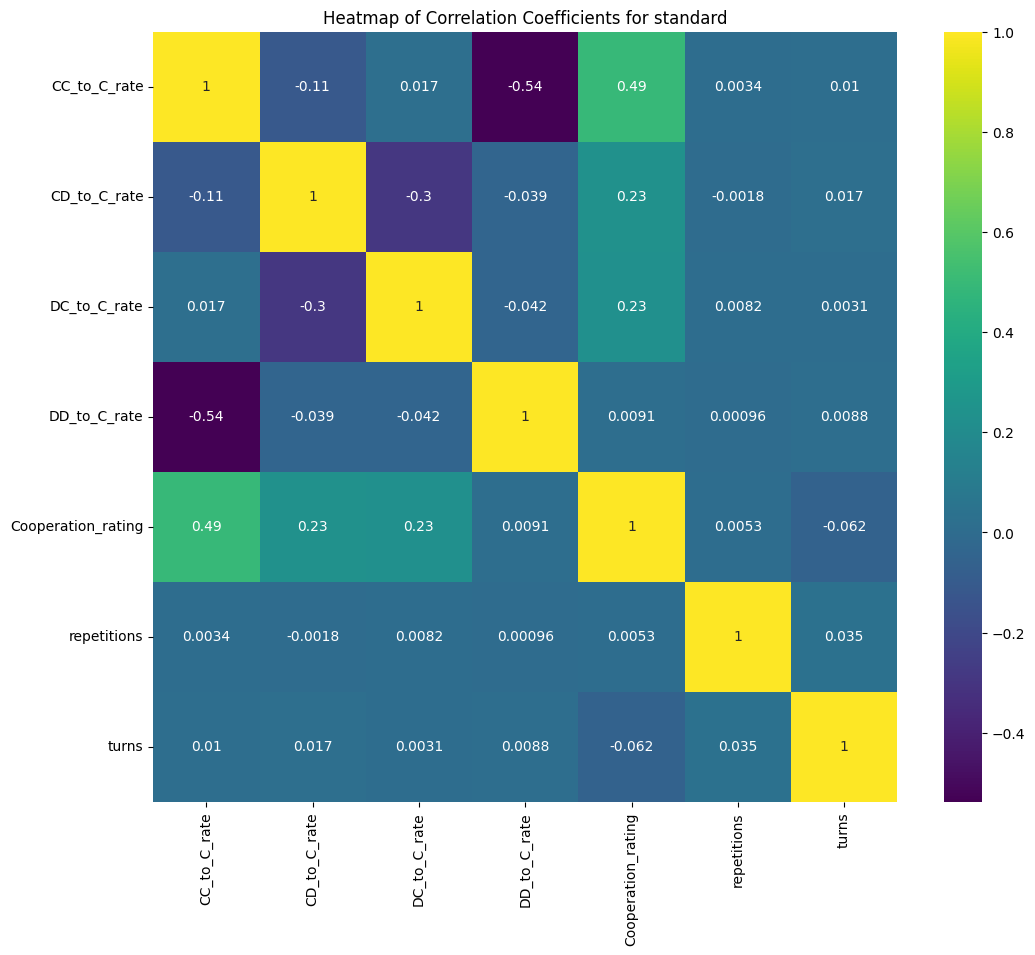

In [ ]:
import seaborn as sns

a_type = types[0]
df = dfs[0] # Select the DataFrame for the specified type
    
xs = features.copy()
xs += ["turns", "memory_usage"]

plt.figure(figsize=(12,10))

xs = [col for col in xs if col in df.columns]

cor = df[xs].corr()

sns.heatmap(cor, annot=True, cmap="viridis")
plt.title('Heatmap of Correlation Coefficients for %s' % a_type)
plt.show()